
### **Goals of this Assignment**

Develop and demonstrate several core skills required for sustainability analyses:

1. Conduct GHG emission calculations via annual (National Inventory Report) and hourly (ASHRAE Standard 242) methods.
2. Conduct peak sizing calculations for heating/cooling systems
3. Visualize building utility/emission data using various methods (time series plots, load/emission duration curves, historgrams, etc)
4. Systems-level approach to envelope, lighting, equipment and mechanical upgrades
5. Conduct rudimentary cost analyses
6. Apply the above using a reproducible pipeline approach

### **Ensure EnergyPlus and genEPJ are installed properly (see Interactive EPlus notebook)**

Download/Install EnergyPlus v25.1 [(here)](https://energyplus.net/downloads)

Set system variables for ENERGYPLUS_DIR and ENERGYPLUS_WEATHER

Copy weather data 'CAN_ON_Ottawa.716280_CWEC.epw' into ENERGYPLUS_WEATHER

Library dependencies (use Anaconda Prompt or Jupyter directly):
* Pandas: conda install pandas OR 'pip install pandas'
* Excel: pip install openpyxl

In [1]:
from os import environ, mkdir
import genEPJ_pkg as ep
from numpy import array, zeros
from numpy import round as rnd

print("Listing personalized final exam values")
import class_tools as ct
A,B,C,D,E=ct.get_values_from_id(101272354) # Your ID goes here

# Option1: Environmental variables setup manually
#eplus_dir = environ['ENERGYPLUS_DIR']

# Option2: Setup environmental variables automatically
mybldg = ep.Building()
mybldg.config.eplus_path_set("C:\EnergyPlusV25-1-0")
eplus_dir = environ['ENERGYPLUS_DIR']
print(eplus_dir)

Loading Cost Data. Encountered Error: Using preset costing data
Using Features Dictionary: {'use_humid_cap': 1, 'use_therm_mass': 1, 'use_win7': 0, 'use_condfd': 0, 'use_daylight': 1, 'pv_model': 1, 'pv_couple': 1, 'grnd_bc': 1, 'enforce_ashrae62': 1, 'timestep': 4, 'solardistribution': 1}
Listing personalized final exam values
Values for id='101272354' A: 71.0%, B: 64.0%, C: 21.2 R-value, D: 46.8 R-value, E: 57.8%
ENERGYPLUS_DIR set to C:\EnergyPlusV25-1-0
ENERGYPLUS_WEATHER set to C:\EnergyPlusV25-1-0\WeatherData
C:\EnergyPlusV25-1-0


In [2]:

# Helper functions

# Horizontal rule block
#hr='<hr style="line-weight: bold;" />'
hr='<hr />'

# Can format strings using markdown: bold: **''**, italics: *''*, ul: "__''__"
from IPython.display import Markdown, display
def printmd(string):
    display(Markdown(string))
    
# Test markdown printing
printmd("**Test** of **markdown** *features* <a src='here'>here</u>")
    

# Make an operating system call
from subprocess import call, Popen, PIPE
def call(command):
    command = command.split(' ')
    return str( Popen(command, stdout=PIPE).communicate()[0]).replace('\n','')

# Lets write a diff function to find IDF objects that are not in a modified file
# This is your friend for understanding changes made to your IDF! It is STRONGLY
# suggested you use this to ensure you're only adding/modifying one object at a time
def diff_IDF(idf1,idf2):
    """Find E+ objects that are in a list of IDF objects call 'idf2' but not in 'idf1'"""
    return [_obj for _obj in idf2 if _obj not in idf1]

# Test
a=['Zone1', 'Zone2']
b=['Zone1', 'Zone2', 'Zone3', 'Zone4']
print( diff_IDF(a,b) ) # should return ['Zone3', 'Zone4']

# Run EnergyPlus file
from os.path import join, splitext, basename # utils for below
from time import time
def run_energyplus(myfile, wfile='fake.epw', run=False, show_html=False):
    # TODO- clean up previous run?
    ep = join(eplus_dir, 'energyplus') # Join with EnergyPlus exe with source directory
    output_dir='data_temp/Output'
    prefix = splitext( basename(myfile) )[0]
    html_file=join(output_dir,prefix+'tbl.htm')
    cmd='{} --expandobjects --readvars --weather {} --output-directory {} --output-prefix {} {}'.format(ep,
                                                                                                        wfile,
                                                                                                        output_dir, 
                                                                                                        prefix, 
                                                                                                        myfile )
    printmd(hr)
    printmd("**Running E+ using:**: \n>{}".format(cmd))
    if run: 
        start_t=time()
        call(cmd)
        stop_t=time()
        print('E+ call took %0.2f min' %((stop_t-start_t)/60.))
        printmd('**E+ ran successfully**')
        if show_html:
            printmd("**HTML results**: <a href='{0}'>{0}</a>".format(html_file))
            printmd('<iframe src="{}" width="100%" height="330" frameborder="0" allowfullscreen>'.format(html_file))
    printmd(hr)

printmd("**Test**: EnergyPlus run")
# Note: we're testing and the function won't run E+ unless 'run=True' is specified
run_energyplus('fake_eplus_file.idf')

# Specify a few useful functions to help us do the heavy lifting
def get_sql_db(idf_file):
    sql_file = join('data_temp','Output', idf_file.replace('.idf','out.sql'))
    if isfile(sql_file):
        return sql_file
    else:
        raise FileNotFoundError(
            "**NO SQLite database file found with name**: '{}'. \
            Try running EnergyPlus on file: '{}'".format(sql_file, idf_file))

import sqlite3
from os.path import isfile, getsize
def get_result(f,varname='Electricity:Facility'):
    def _convert_sql(vals):
        "Convert nested sqlite data '[[1], [2], ...]' to numpy.array: array([1,2,...])"
        _data=list( map(lambda x: x[0], vals ))
        return array(_data)/1e6/3.6 # 1e6: J->MJ, 3.6: MJ->kWh
    _sql_file = get_sql_db(f)
    conn = sqlite3.connect(_sql_file)
    c = conn.cursor()
    sql="SELECT a.VariableValue FROM ReportMeterData as a, \
                ReportMeterDataDictionary as b \
                WHERE a.ReportMeterDataDictionaryIndex=b.ReportMeterDataDictionaryIndex AND \
                b.VariableName='{}';".format(varname)
    mydata= _convert_sql( c.execute(sql).fetchall() )
    conn.close()
    if len(mydata)>0: return mydata
    else:           return zeros(8760)

def get_bldg_area(f):
    def _convert_sql(val):
        "Convert nested sqlite data and convert to float '[1350]' to float: 1350.0"
        return float(val[0])
    sql_file = get_sql_db(f)
    conn = sqlite3.connect(sql_file)
    c = conn.cursor()
    sql_area="SELECT Value FROM TabularDataWithStrings WHERE \
              ReportName='AnnualBuildingUtilityPerformanceSummary' AND \
              RowName='Total Building Area';"
    mydata= _convert_sql( c.execute(sql_area).fetchone() )
    conn.close()
    return mydata

def get_bldg_eui(f, eui_type='Total', print_switch=False):
    def _convert_sql(val):
        "Convert nested sqlite data and convert to float '[117.34, 'kWh/m2']' to float: 117.4, str: 'kWh/m2'"
        return float(val[0]), val[1]
    if eui_type not in ['Total', 'Net']:
        raise ValueError("'{}' Not a valid E+ SQL option.".format(eui_type))
    sql_file = get_sql_db(f)
    conn = sqlite3.connect(sql_file)
    c = conn.cursor()
    sql_eui="SELECT Value,Units FROM TabularDataWithStrings WHERE \
              ReportName='AnnualBuildingUtilityPerformanceSummary' AND \
              ColumnName='Energy Per Total Building Area' AND \
              RowName='{} Site Energy';".format(eui_type)
    #print(sql_eui)
    _eui,_units= _convert_sql( c.execute(sql_eui).fetchone() )
    if print_switch:
        printmd("**{} EUI**: {:.1f} *{}*".format(eui_type, _eui, _units))
    conn.close()
    return _eui,_units

**Test** of **markdown** *features* <a src='here'>here</u>

['Zone3', 'Zone4']


**Test**: EnergyPlus run

<hr />

**Running E+ using:**: 
>C:\EnergyPlusV25-1-0\energyplus --expandobjects --readvars --weather fake.epw --output-directory data_temp/Output --output-prefix fake_eplus_file fake_eplus_file.idf

<hr />

In [3]:
# Attempt to run EnergyPlus on provided file. Show data that might be missing. Add information where necessary
idf_file='Canal_1stFlr.idf'
epw_file='CAN_ON_Ottawa.716280_CWEC.epw'

# Lets try and run this file *as is*
run_energyplus(idf_file, wfile=epw_file, run=True, show_html=False)

# Next, lets perform some tests to ensure we have appropriate data in place in our IDF
idf_objs=ep.get_IDF_objs_raw(idf_file) # Open file and convert to list
print( "Identified {} objects!".format( len(idf_objs) ) )

# Zone objects
objs_zn = ep.filter_IDF_objs_raw(idf_objs, 'Zone')
name_zns = [ zn.split(',')[1].strip() for zn in objs_zn ]
print("Found ZoneNames: {}".format( str(name_zns) ))

#bldg_area=1350 # m2 (from HTML. Can also use SQL)
bldg_area=get_bldg_area(idf_file)
print("Building Area: {} m2".format(bldg_area))

# Hint, hint: This function will be useful for documenting your upgrades below
bldg_eui,     tot_units= get_bldg_eui(idf_file, eui_type="Total", print_switch=True) # Print EUI for Total only
bldg_eui_net, net_units= get_bldg_eui(idf_file, eui_type="Net")
# SB Note: New python trick to try out. We can assign variables on the same line
# Eg. a,b=1,2 # ie. a=1 AND b=1

def overwrite_obj(myobj,objs):
    "Add E+ object. Overwrite if present already."
    idf_obj_type=ep.get_obj_type(myobj)
    new_objs=[obj for obj in objs if ep.get_obj_type(obj)!=idf_obj_type]
    printmd("**Modding:** {}".format(idf_obj_type))
    new_objs.append(myobj)
    return new_objs

def append_if_missing(myobj):
    """Append proposed object if not already present."""
    # EPlus object type: ex. 'Lights', 'Zone', 'BuildingSurfaceDetailed', etc
    idf_obj_type=myobj.split(',')[0]
    
    if not ep.filter_IDF_objs_raw(idf_objs, idf_obj_type):
        printmd("**Adding:** {}".format(idf_obj_type))
        # Append new block to end of IDF
        idf_objs.append(myobj)
        printmd('IDF object type "{}". Adding to IDF'.format(idf_obj_type))
    else:
        printmd("**Type already found:** {}".format(idf_obj_type))
        
# Add other useful details: Output defaults (kWh/m2, HTML, SQL)
append_if_missing('Output:SQLite,SimpleAndTabular;')
idf_objs.append("Output:Meter:MeterFileOnly,Electricity:Facility,hourly;")
idf_objs.append("Output:Meter:MeterFileOnly,Photovoltaic:ElectricityProduced,hourly;")
idf_objs.append("Output:Meter:MeterFileOnly,DistrictHeatingWater:HVAC,hourly;")
idf_objs.append("Output:Meter:MeterFileOnly,DistrictCooling:HVAC,hourly;")
idf_objs.append("Output:Meter:MeterFileOnly,Gas:Facility,hourly;")
idf_objs_mod1=overwrite_obj('OutputControl:Table:Style,HTML,JtoKWH;', idf_objs)

# **!Important!**: idf_objs_mod1 is our basefile that we add upgrades to.
# There are two options to apply building improvements:
#   1. Independently. Apply each upgrade in isolation aka 'one-at-a-time'
#   2. Sequentially. Each upgrade applied sequentially onto the previous upgrade
## **Warning**: Be very careful on the final not to mix these two ideas up.
## *This is the number one mistake from previous years*
# How can you tell the difference? Try using the function 'diff_IDF()'

# Run file again with new options
## Resave IDF using new name
printmd(hr)
startfile=idf_file.replace('.idf', '_mod1.idf')
ep.write_file(idf_objs_mod1, startfile)
## Run the new IDF and present HTML results
run_energyplus(startfile, wfile=epw_file, run=True, show_html=True)
# Show that this function results in the EUI in kWh/m2 (Used in solutions below)
get_bldg_eui(startfile, eui_type="Total", print_switch=True) # Print

<hr />

**Running E+ using:**: 
>C:\EnergyPlusV25-1-0\energyplus --expandobjects --readvars --weather CAN_ON_Ottawa.716280_CWEC.epw --output-directory data_temp/Output --output-prefix Canal_1stFlr Canal_1stFlr.idf

E+ call took 0.05 min


**E+ ran successfully**

<hr />

...

**HTML results**: <a href='data_temp/Output\Canal_1stFlr_mod1tbl.htm'>data_temp/Output\Canal_1stFlr_mod1tbl.htm</a>

<iframe src="data_temp/Output\Canal_1stFlr_mod1tbl.htm" width="100%" height="330" frameborder="0" allowfullscreen>

<hr />

**Total EUI**: 150.8 *kWh/m2*

(150.81, 'kWh/m2')

In [4]:
# Add PV to a roof surface
idf_objs_new = list( idf_objs_mod1) # Save our starting point

# EUI at starting point
get_bldg_eui(startfile, eui_type="Net", print_switch=True)

# Azi==0 is normally north, however it is hardcoded to flat roof surfaces in genEPJ
# Add 18% efficient PV to 50% of flat roof surfaces
#idf_objs_pv=ep.add_PV_by_azi(idf_objs_new, args={ 'frac': 0.5, 'azi': 0, 'pv_eff': 0.18, 'pm': 180, 'Model':'Simple', 'PVcoupled':False, 'file_name': idf_file} )
# Add PV, but set efficiency to 0.0%. Essentially NO PV on roof
idf_objs_pv=ep.add_PV_by_azi(idf_objs_new, args={ 'frac': 0.5, 'azi': 0, 'pv_eff': 0.00, 'pm': 180, 'Model':'Simple', 'PVcoupled':False, 'file_name': idf_file} )

pvfile=idf_file.replace('.idf', '_pv.idf')
ep.write_file(idf_objs_pv, pvfile)
## Run the new IDF and present HTML results
run_energyplus(pvfile, wfile=epw_file, run=True, show_html=True)

# EUI at after adding PV
# SB hint: find a way to subtract EUIs directly (eg. eui_before-eui_after)
pv_eui,pv_units=get_bldg_eui(pvfile, eui_type="Net", print_switch=True)

printmd("**Uncomment below to take a look at what we added:**")
print( '\n'.join( diff_IDF( idf_objs, idf_objs_pv) ) )



**Net EUI**: 150.8 *kWh/m2*

> get_sql: Found database: data_temp\Output\Canal_1stFlrout.sql
Using PV fractional area of 50.0 percent for direction 0
Adding PV objects to SURFACE 8
Saving new file to: Canal_1stFlr_pv.idf


<hr />

**Running E+ using:**: 
>C:\EnergyPlusV25-1-0\energyplus --expandobjects --readvars --weather CAN_ON_Ottawa.716280_CWEC.epw --output-directory data_temp/Output --output-prefix Canal_1stFlr_pv Canal_1stFlr_pv.idf

E+ call took 0.06 min


...

<iframe src="data_temp/Output\Canal_1stFlr_pvtbl.htm" width="100%" height="330" frameborder="0" allowfullscreen>

<hr />

**Net EUI**: 150.8 *kWh/m2*

**Uncomment below to take a look at what we added:**


  Schedule:Constant,
    ALWAYS ON PV 0,               !- Name
    ANY,                     !- Schedule Type Limits Name
    1;                       !- Hourly Value



  Generator:Photovoltaic,
    PV SURFACE 8,!- Name
    SURFACE 8,    !- Surface Name
    PhotovoltaicPerformance:Simple,  !- Photovoltaic Performance Object Type
    16percentEffPV Azi 0 Frac 0.50,   !- Module Performance Name
    Decoupled,               !- Heat Transfer Integration Mode
    1.0,                     !- Number of Series Strings in Parallel {dimensionless}
    1.0;                     !- Number of Modules in Series {dimensionless}



  PhotovoltaicPerformance:Simple,
    16percentEffPV Azi 0 Frac 0.50,!- Name
    0.50,                  !- Fraction of Surface Area with Active Solar Cells {dimensionless}
    Fixed,                !- Conversion Efficiency Input Mode
    0.0;                 !- Value for Cell Efficiency if Fixed



  ElectricLoadCenter:Generators,
    PV list 0,                 !- Name

   

In [5]:
# TIME TO PUT IT ALL TOGETHER

# Substituion time (Ignoring prev PV upgrade):

# !!WARNING: Upgrades are applied SEQUENTIALLY in the following code
# Execute the below changes *one-at-a-time* by commenting out the below instructions.
# All results can be found in HTML tables below

# Save our starting point (Note: 'idf_objs_mod1' defined before PV upgrade)
idf_objs_start = list( idf_objs_mod1)

idf_objs= list(idf_objs_mod1) # This is the list we modify. Note: starting from PV substitution above

refbldg_eui, refbldg_units = get_bldg_eui(startfile, eui_type="Total", print_switch=False)
# Examples on how to modify Lights/Plug Load (aka 'ElectricEquipment')
                        
# Lights: Reduce lighting loads by 50%. Units W/m2
#idf_objs= ep.mod_pd(idf_objs, {'name': 'Lights', 'frac': 0.50} )

## Uncomment if you want to run simulation and see results (lighting upgrade).
## Consider writing in a function for resuse
#light_file=idf_file.replace('.idf', '_lights.idf') #light_file=idf_file.replace('.idf', '_lights.idf')
#ep.write_file(idf_objs, light_file) #ep.write_file(idf_objs, light_file)
## Run simulation and see results
#run_energyplus(light_file, wfile=epw_file, run=True, show_html=False) #run_energyplus(light_file, wfile=epw_file, run=True, show_html=False)
#_e,_u=get_bldg_eui(light_file, eui_type="Total", print_switch=True) #_e,_u=get_bldg_eui(light_file, eui_type="Total", print_switch=True)
#print( "Delta savings: {:,.2f} kWh/m2".format( refbldg_eui-_e )) #print( "Delta savings: {:,.2f} kWh/m2".format( refbldg_eui-_e ))
#printmd("**Lets take a look at what we modified for LIGHTING upgrades:**") #printmd("**Lets take a look at what we modified for LIGHTING upgrades:**")
#print( '\n\n'.join( diff_IDF( idf_objs_start, idf_objs) ) ) #print( '\n\n'.join( diff_IDF( idf_objs_start, idf_objs) ) )
## Uncomment below to reset to first step ('one at a time' changes)
#idf_objs= list(idf_objs_mod1) ## idf_objs= list(idf_objs_mod1)
#printmd(hr)

# Lights: Reduce lighting loads by A%. Units W/m2
idf_objs= ep.mod_pd(idf_objs, {'name': 'Lights', 'frac': 0.29} )

## Uncomment if you want to run simulation and see results (lighting upgrade).
## Consider writing in a function for resuse
light_file=idf_file.replace('.idf', '_lights.idf') #light_file=idf_file.replace('.idf', '_lights.idf')
ep.write_file(idf_objs, light_file) #ep.write_file(idf_objs, light_file)
## Run simulation and see results
run_energyplus(light_file, wfile=epw_file, run=True, show_html=False) #run_energyplus(light_file, wfile=epw_file, run=True, show_html=False)
_e,_u=get_bldg_eui(light_file, eui_type="Total", print_switch=True) #_e,_u=get_bldg_eui(light_file, eui_type="Total", print_switch=True)
print( "Delta savings: {:,.2f} kWh/m2".format( refbldg_eui-_e )) #print( "Delta savings: {:,.2f} kWh/m2".format( refbldg_eui-_e ))
#printmd("**Lets take a look at what we modified for LIGHTING 2 upgrades:**") #printmd("**Lets take a look at what we modified for LIGHTING upgrades:**")
#print( '\n\n'.join( diff_IDF( idf_objs_start, idf_objs) ) ) #print( '\n\n'.join( diff_IDF( idf_objs_start, idf_objs) ) )
## Uncomment below to reset to first step ('one at a time' changes)
#idf_objs= list(idf_objs_mod1) ## idf_objs= list(idf_objs_mod1)
printmd(hr)

# Plug Loads: Reduce ElectricEquipment loads by 30%. Units W/m2.
# NOTE: upgrade applied to 'idf_objs' which includes the prev lighting upgrade
#idf_objs= ep.mod_pd(idf_objs, {'name': 'ElectricEquipment', 'frac': 0.70} )

#ElectricEquipment_file=idf_file.replace('.idf', '_ElectricEquipment.idf') #light_file=idf_file.replace('.idf', '_lights.idf')
#ep.write_file(idf_objs, ElectricEquipment_file) #ep.write_file(idf_objs, light_file)

#run_energyplus(ElectricEquipment_file, wfile=epw_file, run=True, show_html=False) #run_energyplus(light_file, wfile=epw_file, run=True, show_html=False)
#_e,_u=get_bldg_eui(ElectricEquipment_file, eui_type="Total", print_switch=True) #_e,_u=get_bldg_eui(light_file, eui_type="Total", print_switch=True)
#print( "Delta savings: {:,.2f} kWh/m2".format( refbldg_eui-_e ))
#printmd("**Lets take a look at what we modified for Electric Equipment upgrades:**")
#print( '\n\n'.join( diff_IDF( idf_objs_start, idf_objs) ) )
#idf_objs= list(idf_objs_mod1)
#printmd(hr)

# Plug Loads: Reduce ElectricEquipment loads by B%. Units W/m2.
# NOTE: upgrade applied to 'idf_objs' which includes the prev lighting upgrade
idf_objs= ep.mod_pd(idf_objs, {'name': 'ElectricEquipment', 'frac': 0.36} )

ElectricEquipment_file=idf_file.replace('.idf', '_ElectricEquipment.idf') #light_file=idf_file.replace('.idf', '_lights.idf')
ep.write_file(idf_objs, ElectricEquipment_file) #ep.write_file(idf_objs, light_file)

run_energyplus(ElectricEquipment_file, wfile=epw_file, run=True, show_html=False) #run_energyplus(light_file, wfile=epw_file, run=True, show_html=False)
_e,_u=get_bldg_eui(ElectricEquipment_file, eui_type="Total", print_switch=True) #_e,_u=get_bldg_eui(light_file, eui_type="Total", print_switch=True)
print( "Delta savings: {:,.2f} kWh/m2".format( refbldg_eui-_e ))
#printmd("**Lets take a look at what we modified for Electric Equipment 2 upgrades:**")
#print( '\n\n'.join( diff_IDF( idf_objs_start, idf_objs) ) )
#idf_objs= list(idf_objs_mod1)
printmd(hr)

# Example on how to modify insulation
## Note: Below we commit a faux pas of changing the conductivity of a material rather than its thickness. 

# Roof: Construction containing 'ExtWall'
# Below Matches: ASHRAE 189.1-2009 **ExtWall** Mass ClimateZone 5
#idf_objs = ep.mod_insul(idf_objs, args={'name':'ExtWall', 'loc': "ExtWall", 'resis': 24} ) # R-value=24 (nominal)

#ExtWall_file=idf_file.replace('.idf', '_ExtWall.idf') #light_file=idf_file.replace('.idf', '_lights.idf')
#ep.write_file(idf_objs, ExtWall_file) #ep.write_file(idf_objs, light_file)

#run_energyplus(ExtWall_file, wfile=epw_file, run=True, show_html=False) #run_energyplus(light_file, wfile=epw_file, run=True, show_html=False)
#_e,_u=get_bldg_eui(ExtWall_file, eui_type="Total", print_switch=True) #_e,_u=get_bldg_eui(light_file, eui_type="Total", print_switch=True)
#print( "Delta savings: {:,.2f} kWh/m2".format( refbldg_eui-_e ))
#printmd("**Lets take a look at what we modified for ExtWall upgrades:**")
#print( '\n\n'.join( diff_IDF( idf_objs_start, idf_objs) ) )
#idf_objs= list(idf_objs_mod1)
#printmd(hr)

idf_objs = ep.mod_insul(idf_objs, args={'name':'ExtWall', 'loc': "ExtWall", 'resis': 21.2} ) # R-value=24 (nominal)

ExtWall_file=idf_file.replace('.idf', '_ExtWall.idf') #light_file=idf_file.replace('.idf', '_lights.idf')
ep.write_file(idf_objs, ExtWall_file) #ep.write_file(idf_objs, light_file)

run_energyplus(ExtWall_file, wfile=epw_file, run=True, show_html=False) #run_energyplus(light_file, wfile=epw_file, run=True, show_html=False)
_e,_u=get_bldg_eui(ExtWall_file, eui_type="Total", print_switch=True) #_e,_u=get_bldg_eui(light_file, eui_type="Total", print_switch=True)
print( "Delta savings: {:,.2f} kWh/m2".format( refbldg_eui-_e ))
#printmd("**Lets take a look at what we modified for ExtWall 2 upgrades:**")
#print( '\n\n'.join( diff_IDF( idf_objs_start, idf_objs) ) )
#idf_objs= list(idf_objs_mod1)
printmd(hr)

# Roof: Construction containing 'ExtRoof'
# Below Matches: ASHRAE 189.1-2009 **ExtRoof** IEAD ClimateZone 2-5
#idf_objs = ep.mod_insul(idf_objs, args={'name':'ExtRoof', 'loc': "ExtRoof", 'resis': 40.0}) # R-value=40 (nominal)

#ExtRoof_file=idf_file.replace('.idf', '_ExtRoof.idf') #light_file=idf_file.replace('.idf', '_lights.idf')
#ep.write_file(idf_objs, ExtRoof_file) #ep.write_file(idf_objs, light_file)

#run_energyplus(ExtRoof_file, wfile=epw_file, run=True, show_html=False) #run_energyplus(light_file, wfile=epw_file, run=True, show_html=False)
#_e,_u=get_bldg_eui(ExtRoof_file, eui_type="Total", print_switch=True) #_e,_u=get_bldg_eui(light_file, eui_type="Total", print_switch=True)
#print( "Delta savings: {:,.2f} kWh/m2".format( refbldg_eui-_e ))
#printmd("**Lets take a look at what we modified for ExtRoof upgrades:**")
#print( '\n\n'.join( diff_IDF( idf_objs_start, idf_objs) ) )
#idf_objs= list(idf_objs_mod1)
#printmd(hr)

idf_objs = ep.mod_insul(idf_objs, args={'name':'ExtRoof', 'loc': "ExtRoof", 'resis': 46.8}) # R-value=D

ExtRoof_file=idf_file.replace('.idf', '_ExtRoof.idf') #light_file=idf_file.replace('.idf', '_lights.idf')
ep.write_file(idf_objs, ExtRoof_file) #ep.write_file(idf_objs, light_file)

run_energyplus(ExtRoof_file, wfile=epw_file, run=True, show_html=False) #run_energyplus(light_file, wfile=epw_file, run=True, show_html=False)
_e,_u=get_bldg_eui(ExtRoof_file, eui_type="Total", print_switch=True) #_e,_u=get_bldg_eui(light_file, eui_type="Total", print_switch=True)
print( "Delta savings: {:,.2f} kWh/m2".format( refbldg_eui-_e ))
#printmd("**Lets take a look at what we modified for ExtRoof 2 upgrades:**")
#print( '\n\n'.join( diff_IDF( idf_objs_start, idf_objs) ) )
#idf_objs= list(idf_objs_mod1)
printmd(hr)

# Improve air-tightness (aka infiltration) by 20%. Units m3/s/m2
#idf_objs= ep.mod_infil(idf_objs, args={ 'frac': 0.8} )


#Infiltration_file=idf_file.replace('.idf', '_Infiltration.idf') #light_file=idf_file.replace('.idf', '_lights.idf')
#ep.write_file(idf_objs, Infiltration_file) #ep.write_file(idf_objs, light_file)

#run_energyplus(Infiltration_file, wfile=epw_file, run=True, show_html=False) #run_energyplus(light_file, wfile=epw_file, run=True, show_html=False)
#_e,_u=get_bldg_eui(Infiltration_file, eui_type="Total", print_switch=True) #_e,_u=get_bldg_eui(light_file, eui_type="Total", print_switch=True)
#print( "Delta savings: {:,.2f} kWh/m2".format( refbldg_eui-_e ))
#printmd("**Lets take a look at what we modified for Infiltration upgrades:**")
#print( '\n\n'.join( diff_IDF( idf_objs_start, idf_objs) ) )
#idf_objs= list(idf_objs_mod1)
#printmd(hr)

# Improve air-tightness (aka infiltration) by D%. Units m3/s/m2
idf_objs= ep.mod_infil(idf_objs, args={ 'frac': 0.42} ) #was 0.8


Infiltration_file=idf_file.replace('.idf', '_Infiltration.idf') #light_file=idf_file.replace('.idf', '_lights.idf')
ep.write_file(idf_objs, Infiltration_file) #ep.write_file(idf_objs, light_file)

run_energyplus(Infiltration_file, wfile=epw_file, run=True, show_html=False) #run_energyplus(light_file, wfile=epw_file, run=True, show_html=False)
_e,_u=get_bldg_eui(Infiltration_file, eui_type="Total", print_switch=True) #_e,_u=get_bldg_eui(light_file, eui_type="Total", print_switch=True)
print( "Delta savings: {:,.2f} kWh/m2".format( refbldg_eui-_e ))
#printmd("**Lets take a look at what we modified for Infiltration 2 upgrades:**")
#print( '\n\n'.join( diff_IDF( idf_objs_start, idf_objs) ) )
#idf_objs= list(idf_objs_mod1)
printmd(hr)

# Run file with above changes
## Resave IDF using new name
printmd(hr)
newfile=idf_file.replace('.idf', '_modall.idf')
ep.write_file(idf_objs, newfile)
## Run the new IDF and present HTML results
run_energyplus(newfile, wfile=epw_file, run=True, show_html=True)

printmd("**Lets take a look at what we modified for ALL upgrades:**")
print( '\n\n'.join( diff_IDF( idf_objs_start, idf_objs) ) )

# ============================================================
# AUTOMATIC EUI SAVINGS TABLE FOR ALL UPGRADES
# ============================================================

import pandas as pd

# Baseline and file mapping
baseline_eui = refbldg_eui

upgrade_files = {
    "Lights Upgrade A (29%)"           : light_file,
    "Plug Load Upgrade B (36%)"        : ElectricEquipment_file,
    "Wall Insulation Upgrade (R=21.2)" : ExtWall_file,
    "Roof Insulation Upgrade (R=46.8)" : ExtRoof_file,
    "Infiltration Upgrade (frac=0.42)" : Infiltration_file,
    "All Upgrades Combined"            : newfile
}

results = []

for upgrade_name, file in upgrade_files.items():
    try:
        eui, _ = get_bldg_eui(file, eui_type="Total", print_switch=False)
        delta = baseline_eui - eui

        results.append({
            "Upgrade"        : upgrade_name,
            "Resulting EUI"  : eui,
            "Savings (kWh/m²)" : delta
        })
    except Exception as e:
        results.append({
            "Upgrade"        : upgrade_name,
            "Resulting EUI"  : "ERROR",
            "Savings (kWh/m²)" : "ERROR"
        })

# Create a clean savings table
df_results = pd.DataFrame(results)

printmd("## **Automatic Incremental EUI Savings Summary**")
df_results 

# -------------------------
# AUTO: Q13-14 summary (add to BOTTOM of notebook)
# -------------------------
from os.path import exists

# Ensure baseline EUI variable exists or read it from startfile
try:
    refbldg_eui  # if defined earlier, fine
except NameError:
    refbldg_eui, refbldg_units = get_bldg_eui(startfile, eui_type="Total", print_switch=False)

# Ensure final combined file name exists (newfile from your code)
try:
    newfile  # should be defined by your existing code
except NameError:
    newfile = idf_file.replace('.idf', '_modall.idf')

# --------------------------------------------------------------------
# Define independent upgrade functions (apply to a fresh copy of baseline)
# These match the exact upgrades you used above (lighting 0.29, equip 0.36,
# wall resis 21.2, roof resis 46.8, infiltration frac 0.42).
# --------------------------------------------------------------------
def run_independent_light():
    idf_copy = list(idf_objs_start)
    idf_copy = ep.mod_pd(idf_copy, {'name': 'Lights', 'frac': 0.29})
    out = idf_file.replace('.idf', '_ind_lights.idf')
    ep.write_file(idf_copy, out)
    run_energyplus(out, wfile=epw_file, run=True, show_html=False)
    return get_bldg_eui(out, eui_type="Total", print_switch=False)

def run_independent_equip():
    idf_copy = list(idf_objs_start)
    idf_copy = ep.mod_pd(idf_copy, {'name': 'ElectricEquipment', 'frac': 0.36})
    out = idf_file.replace('.idf', '_ind_equip.idf')
    ep.write_file(idf_copy, out)
    run_energyplus(out, wfile=epw_file, run=True, show_html=False)
    return get_bldg_eui(out, eui_type="Total", print_switch=False)

def run_independent_extwall():
    idf_copy = list(idf_objs_start)
    idf_copy = ep.mod_insul(idf_copy, args={'name':'ExtWall', 'loc': "ExtWall", 'resis': 21.2})
    out = idf_file.replace('.idf', '_ind_extwall.idf')
    ep.write_file(idf_copy, out)
    run_energyplus(out, wfile=epw_file, run=True, show_html=False)
    return get_bldg_eui(out, eui_type="Total", print_switch=False)

def run_independent_extroof():
    idf_copy = list(idf_objs_start)
    idf_copy = ep.mod_insul(idf_copy, args={'name':'ExtRoof', 'loc': "ExtRoof", 'resis': 46.8})
    out = idf_file.replace('.idf', '_ind_extroof.idf')
    ep.write_file(idf_copy, out)
    run_energyplus(out, wfile=epw_file, run=True, show_html=False)
    return get_bldg_eui(out, eui_type="Total", print_switch=False)

def run_independent_infil():
    idf_copy = list(idf_objs_start)
    idf_copy = ep.mod_infil(idf_copy, args={ 'frac': 0.42})
    out = idf_file.replace('.idf', '_ind_infil.idf')
    ep.write_file(idf_copy, out)
    run_energyplus(out, wfile=epw_file, run=True, show_html=False)
    return get_bldg_eui(out, eui_type="Total", print_switch=False)

# --------------------------------------------------------------------
# Run (or reuse previously created outputs) and collect EUIs
# --------------------------------------------------------------------
# Baseline (Total) - print for clarity
printmd("=== Q13 — Baseline & Proposed EUI ===")
ref_eui, _ = get_bldg_eui(startfile, eui_type="Total", print_switch=True)  # reference

# Whole-building (all upgrades) EUI from your 'newfile' run
if exists(newfile):
    whole_eui, _ = get_bldg_eui(newfile, eui_type="Total", print_switch=True)
else:
    # If final combined not yet run, run it now (safe fallback)
    ep.write_file(idf_objs, newfile)
    run_energyplus(newfile, wfile=epw_file, run=True, show_html=False)
    whole_eui, _ = get_bldg_eui(newfile, eui_type="Total", print_switch=True)

printmd("\n=== Q14 — Sum-of-parts (independent) runs ===")

# Perform independent runs (these will write/re-run EnergyPlus)
_e_light, _u_light = run_independent_light()
print("Lighting-only EUI: {:.2f} {}".format(_e_light, _u_light))

_e_equip, _u_equip = run_independent_equip()
print("ElectricEquip-only EUI: {:.2f} {}".format(_e_equip, _u_equip))

_e_wall, _u_wall = run_independent_extwall()
print("ExtWall-only EUI: {:.2f} {}".format(_e_wall, _u_wall))

_e_roof, _u_roof = run_independent_extroof()
print("ExtRoof-only EUI: {:.2f} {}".format(_e_roof, _u_roof))

_e_infil, _u_infil = run_independent_infil()
print("Infiltration-only EUI: {:.2f} {}".format(_e_infil, _u_infil))

# --------------------------------------------------------------------
# Compute incremental savings
# --------------------------------------------------------------------
independent_euis = {
    'Lighting': _e_light,
    'ElectricEquip': _e_equip,
    'ExtWall': _e_wall,
    'ExtRoof': _e_roof,
    'Infiltration': _e_infil
}

# Sum-of-parts incremental savings = sum(baseline - each_independent)
sum_of_parts = sum([ref_eui - v for v in independent_euis.values()])

# Whole-building incremental savings = baseline - EUI(all upgrades)
whole_building_saving = ref_eui - whole_eui

# Percent error comparing sum-of-parts to whole-building
if whole_building_saving != 0:
    percent_error = (sum_of_parts - whole_building_saving) / whole_building_saving * 100.0
else:
    percent_error = float('inf')

# Print neat summary
printmd("=== RESULTS (Q13 & Q14) ===")
print("Original/Reference building EUI (kWh/m2): {:.2f}".format(ref_eui))
print("New/Proposed building EUI (kWh/m2)    : {:.2f}".format(whole_eui))
print()
print("Incremental EUI savings (sum-of-parts) : {:.2f} kWh/m2".format(sum_of_parts))
print("Incremental EUI savings (whole-building): {:.2f} kWh/m2".format(whole_building_saving))
print("Percent error (sum-parts vs whole)     : {:.2f} %".format(percent_error))

# Optional: show table of independent contributions
printmd("**Independent runs (baseline -> each)**")
for k,v in independent_euis.items():
    print("{:12s} : EUI = {:.2f}, incremental vs baseline = {:.2f} kWh/m2".format(k, v, ref_eui - v))

# You can copy-paste the printed lines into your PDF answers for Q13-15.


Replacing PowerDensity of '189.1-2009 - Office - OpenOffice - CZ4-8 Lights' from '10.656271' to '3.09031859'
Saving new file to: Canal_1stFlr_lights.idf


<hr />

**Running E+ using:**: 
>C:\EnergyPlusV25-1-0\energyplus --expandobjects --readvars --weather CAN_ON_Ottawa.716280_CWEC.epw --output-directory data_temp/Output --output-prefix Canal_1stFlr_lights Canal_1stFlr_lights.idf

E+ call took 0.06 min


**E+ ran successfully**

...

Infiltration-only EUI: 136.42 kWh/m2


=== RESULTS (Q13 & Q14) ===

Original/Reference building EUI (kWh/m2): 150.81
New/Proposed building EUI (kWh/m2)    : 94.28

Incremental EUI savings (sum-of-parts) : 57.69 kWh/m2
Incremental EUI savings (whole-building): 56.53 kWh/m2
Percent error (sum-parts vs whole)     : 2.05 %


**Independent runs (baseline -> each)**

Lighting     : EUI = 130.94, incremental vs baseline = 19.87 kWh/m2
ElectricEquip : EUI = 134.43, incremental vs baseline = 16.38 kWh/m2
ExtWall      : EUI = 148.86, incremental vs baseline = 1.95 kWh/m2
ExtRoof      : EUI = 145.71, incremental vs baseline = 5.10 kWh/m2
Infiltration : EUI = 136.42, incremental vs baseline = 14.39 kWh/m2


In [6]:

# Lets plot some data:
from matplotlib import pyplot as plt, rcParams

# Plot size in inches
rcParams['figure.figsize'] = [10, 8] # inches

# Final modifications: We change heating/cooling systems by manipulating
# the efficiency of heating/cooling loads and assign them to an appropriate meter 

#----------------------------------WARNING----------------------------------------
# Be careful how you approach below. Electric boilers and heat pumps should be assigned to electricity
## Warning: EUIs from E+ results won't be accurate beyond this point. DONT USE get_bldg_eui()!! Calculate directly as per below

## Facility Electricity and Natural Gas Meters
#data_elec=get_result(newfile, 'Electricity:Facility') # Electricity (kWh)
#data_ngas=get_result(newfile, 'Gas:Facility') # Natural Gas (if any; kWh_eq [equivalent])

# Following variables are needed for IdealLoad HVAC Systems

## NATURAL GAS BUILDING (gas boiler, electric chiller)
## Assume mechanical equipment efficiencies as per below to size natural gas boiler (heating), and chiller (cooling)
#data_heat=get_result(newfile, 'DistrictHeatingWater:HVAC')/0.9 # Assumes gas condensing boiler
#data_cool=get_result(newfile, 'DistrictCooling:HVAC')/4.0 # Assumes a efficient chiller (COP=4)
#data_pv=get_result(newfile, 'Photovoltaic:ElectricityProduced') # PV generation (if any)
#data_elec=data_elec+data_cool-data_pv # Cooling assigned to electrical meter
#data_ngas=data_ngas+data_heat # Heating assigned to gas meter
#data_bldg=data_elec+data_ngas # kWheq (mixing heat with electricity!)

# Electrified BUILDING (electric boiler, chiller)
# Assume mechanical equipment efficiencies as per below to size natural gas boiler (heating), and chiller (cooling)
# Warning!: How would you model a heat pump using Ideal loads?
#data_heat=get_result(newfile, 'DistrictHeatingWater:HVAC')/1 # Assumes a natural gas boiler
#data_cool=get_result(newfile, 'DistrictCooling:HVAC')/4.0 # Assumes a efficient chiller (COP=4)
#data_pv=get_result(newfile, 'Photovoltaic:ElectricityProduced') # PV generation (if any)
#data_elec=data_elec+data_heat+data_cool-data_pv # Cooling assigned to electrical meter
#data_ngas=data_ngas # 'Gas:Facility' Meter only
#data_bldg=data_elec+data_ngas # kWheq

# Interpreting results:

## Energy: Number formatting- '.1f:' rounds to one decimal place, ':,' use comma's as separators
#print( "Total energy of building (kWh): {:,.0f}".format( sum(data_bldg) ))

## EUI:
#3print( "Total energy use intensity of building (kWh/m2): {:,.1f}. Area of {}m2".format( sum(data_bldg)/bldg_area, bldg_area ))

## Peak heating load (sizing calculation):
#print( "Boiler size (kWeq): {:,.1f}".format( max(data_heat)))

## Peak cooling load (sizing calculation):
#print( "Chiller size (kW): {:,.1f}".format( max(data_cool)))

data_elec=get_result(newfile, 'Electricity:Facility') # Electricity (kWh)
data_ngas=get_result(newfile, 'Gas:Facility') # Natural Gas (if any; kWh_eq [equivalent])

data_heat=get_result(newfile, 'DistrictHeatingWater:HVAC')/5 # Assumes heat pump (5)
data_cool=get_result(newfile, 'DistrictCooling:HVAC')/4.0 # Assumes a efficient chiller (COP=4)
data_pv=get_result(newfile, 'Photovoltaic:ElectricityProduced') # PV generation (if any)
data_elec=data_elec+data_heat+data_cool-data_pv # Cooling assigned to electrical meter
data_ngas=data_ngas # 'Gas:Facility' Meter only
data_bldg=data_elec+data_ngas # kWheq

## Energy: Number formatting- '.1f:' rounds to one decimal place, ':,' use comma's as separators
print( "Total energy of building (kWh): {:,.0f}".format( sum(data_bldg) ))

## EUI:
print( "Total energy use intensity of building (kWh/m2): {:,.1f}. Area of {}m2".format( sum(data_bldg)/bldg_area, bldg_area ))

## Peak heating load (sizing calculation):
print( "Boiler size (kWeq): {:,.1f}".format( max(data_heat)))

## Peak cooling load (sizing calculation):
print( "Chiller size (kW): {:,.1f}".format( max(data_cool)))

# Interactive plot(!)
#%matplotlib notebook
#plt.plot(data_bldg)
#plt.ylabel('Energy, kWh')
#plt.xlabel('Time, h')



Total energy of building (kWh): 50,640
Total energy use intensity of building (kWh/m2): 37.5. Area of 1350.0m2
Boiler size (kWeq): 13.4
Chiller size (kW): 9.3


**Starting emission calculations:**

**Building emissions using federal values:** 2 metric tonnes

**Starting hourly analysis...**

Columns in data sheet: Index(['Timestep', 'Ontario', 'Northwest', 'Northeast', 'Ottawa', 'East',
       'Toronto', 'Essa', 'Bruce', 'Southwest', 'Niagara', 'West'],
      dtype='object')
Len of data: 8760
Try and manually check first/last values from the dataset: first is 40.45gCO2/kWh,
           last is 2.81gCO2/kwh


**Building emissions using hourly values:** 0 metric tonnes

Max Metric Tons:
0.4463358067697553
Federal Metric Tons:
1.9243286179280414


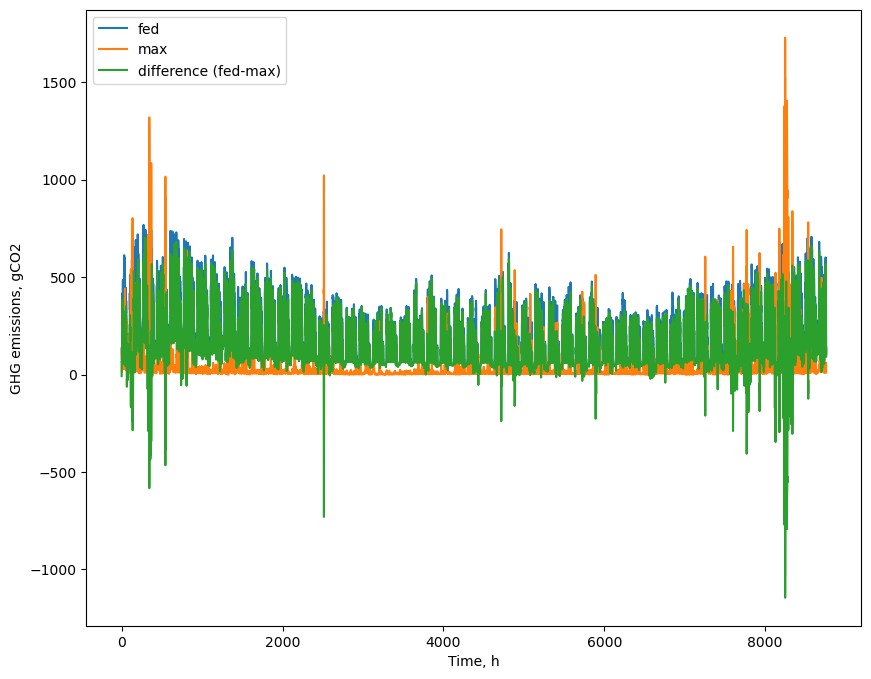

In [7]:
# Next is GHG emissions
printmd("**Starting emission calculations:**")

if(sum(data_pv)>0):
    printmd("**Remove PV substitution above OR set PV panel efficiency to 0%**")
    raise ValueError("No PV beyond this point!")

## Start with a flat factor analysis

gCO2_elec=38    # gCO2e/kWh (2025 Emission factor for Ontario electricity). Source: https://www.canada.ca/en/environment-climate-change/services/climate-change/pricing-pollution-how-it-will-work/output-based-pricing-system/federal-greenhouse-gas-offset-system/emission-factors-reference-values.html
gCO2_ngas_m3=1921 # gCO2e/m3 (2025 Emission factor for Natural Gas)
gas2kWh=10.33 # kWh_eq/m3 # See: https://www.nrcan.gc.ca/energy/publications/efficiency/buildings/5985#d
gCO2_ngas= gCO2_ngas_m3/gas2kWh # gCO2e/kWh_eq
# NOTE: If you were used propane instead of natural gas, you'd use 1515gCO2/L for emissions and 7.09kWh_eq/L to convert from kWh_eq to liters of propane.

ghg_fed_gCO2_hourly= (data_elec)*gCO2_elec + (data_ngas)*gCO2_ngas
ghg_fed_ton_hourly= ghg_fed_gCO2_hourly/1000/1000 # metric tonnes: 1ton=1000kg. 1kg=1000g. Note imperial ton==2000lbs (ie. 1tonne=1.102ton imperial)
printmd("**Building emissions using federal values:** {:,.0f} metric tonnes".format( sum(ghg_fed_ton_hourly) ))

# Next hourly GHG emission analysis (Courtesy of Max)
## Read in csv file using pandas
printmd("**Starting hourly analysis...**")
import pandas as pd
#from pandas import ExcelFile
#location='Ottawa'
df = pd.read_excel('DemandBased_EF_2016_2017_2018.xlsx') # Called a *dataframe*. Used in python/R to slice up data
print("Columns in data sheet: {}".format(df.columns)) # We'll use 'Ottawa'
all_ottawa_data=df['Ottawa']
#all_ottawa_data=df['Ontario']
num_pts=len(all_ottawa_data)
start_slice=num_pts-8760-1 # Start of 2018 data. End is '-1' index (see intro to python lecture)
gCO2_elec_hourly= array( all_ottawa_data[start_slice:-1]) # 2018 data from Excel spreadsheet
# Test:
print("Len of data: {}".format( len(gCO2_elec_hourly) ))
print("""Try and manually check first/last values from the dataset: first is {:.2f}gCO2/kWh,
           last is {:.2f}gCO2/kwh""".format(gCO2_elec_hourly[0], gCO2_elec_hourly[-1]))

## Get the data we want: (!)Use hourly, not annual values(!)
ghg_max_gCO2_hourly= (data_elec)*gCO2_elec_hourly \
                    + (data_ngas)*gCO2_ngas
ghg_max_ton_hourly= ghg_max_gCO2_hourly/1000/1000 # metric tonnes: 1ton=1000kg. 1kg=1000g. Note imperial ton==2000lbs (ie. 1tonne=1.102ton imperial)

printmd("**Building emissions using hourly values:** {:,.0f} metric tonnes".format( sum(ghg_max_ton_hourly) ))

print("Max Metric Tons:") 
print(sum(ghg_max_ton_hourly))

print("Federal Metric Tons:") 
print(sum(ghg_fed_ton_hourly))

# Uncomment if plot stops showing up
#%matplotlib inline
#import matplotlib.pyplot as plt
#from IPython.display import display

# Plot and compare the differences between them
fig, ax = plt.subplots()
ax.plot(ghg_fed_gCO2_hourly, label='fed', alpha=1.0)
ax.plot(ghg_max_gCO2_hourly, label='max', alpha=1.0)
ax.plot(ghg_fed_gCO2_hourly-ghg_max_gCO2_hourly, label='difference (fed-max)')
# Notice any interesting differences? Try and plot just the difference (comment out other plot statements)
ax.set_xlabel('Time, h')
ax.set_ylabel('GHG emissions, gCO2')
ax.legend()
display(fig)
plt.close('all')



In [8]:
# Introduction to emission duration curves. What is the impact of avoiding high emission events?
#printmd("[Link to full publication (St. Jacques, 2022)](./pdfs/5_EDCs.pdf)")

# NOTES: Building model definition as per GHG analysis above

# Steps:
# 1. electrify your building (heat pump/baseboard heating)
# 2. Confirm your data and emission files are correct (need to use **AMY and EFs for the same year**)
# 3. Confirm you are saving to and using the same CSV file

# Test: Is there natural gas in use?
if sum(data_ngas)>0:
    raise ValueError("Your building uses natural gas. Electrify your building and try again")

# Test: Is there PV in use?
if sum(data_pv)!=0:
    raise ValueError("Your building has photovoltaics. Remove PV and try again (keep it simple)")


# 1. Data creation
ghg_event_csv='data/2025.csv'
#ghg_event_csv='data/2018.csv'
df = pd.DataFrame({
    'TS': range(1, len(data_elec) + 1),
    'elec[kWh]': data_elec,
    'annual_GHG_elec[tonnes]': ghg_fed_ton_hourly,
    'hourly_GHG_elec[tonnes]': ghg_max_ton_hourly,
    'gas[m3]': zeros(8760),
    'annual_EF_gas[tonnes]': zeros(8760),
    'gas2elec[kWh]': zeros(8760),
    'annual_EF_gas2elec[tonnes]': zeros(8760),
    'hourly_GHG_gas2elec[tonnes]': zeros(8760)
})

# Save to CSV
if '2025' in ghg_event_csv:
    df.to_csv(ghg_event_csv, index=False)

# 2. Data visualization
#%run scripts/EDC_events.py {ghg_event_csv} # Run with event labels of high emission events
#%run scripts/EDC_events.py {ghg_event_csv} nolabel # Run without labels


# 3. Event isolation (Top N emission events)
import sys
sys.path.append('scripts')
from EDC_events import get_events
event_list,orig_data,dates=get_events(ghg_event_csv, flag_peak_stats=False) # Without event stats this time
total_ghg_ton=sum( map(sum, event_list))

num_peak_events=10
peak_events_ghg_ton=[]
print("Peak 'N' Events loop:")
for _N in range(num_peak_events):
    peak_events_ghg_ton.append( sum(event_list[_N]) )
    print(f"Peak Event {_N+1}: {sum(event_list[_N]):.4f} ton")

# 4. Impact of avoiding peak GHG events
print(f"Total GHG emissions from all events: {total_ghg_ton:.4f} ton")

# ---------------------------------------------------------------
# 5. Required hours of self-powering to reduce GHG by 15%
# ---------------------------------------------------------------

target_reduction = 0.15   # 15%
total_GHG = total_ghg_ton
required_reduction = total_GHG * target_reduction

print(f"\nTotal annual GHG emissions: {total_GHG:.4f} ton")
print(f"Required reduction (15%): {required_reduction:.4f} ton\n")

# event_list is already sorted high → low (from the earlier code)
cumulative_reduction = 0
required_hours = 0
events_used = []

for ev in event_list:
    ev_ghg = sum(ev)
    cumulative_reduction += ev_ghg
    required_hours += len(ev)
    events_used.append(ev)

    if cumulative_reduction >= required_reduction:
        break

print("------------------------------------------------")
print(f"Hours of self-power needed: {required_hours} h")
print(f"GHG reduction achieved: {cumulative_reduction:.4f} ton")
print("------------------------------------------------\n")

# ---------------------------------------------------------------
# 6. Percentage of the year this represents
# ---------------------------------------------------------------
pct_year = required_hours / 8760 * 100
print(f"Percentage of year self-powered: {pct_year:.2f}%")

Number of events:  1434
Peak 'N' Events loop:
Peak Event 1: 0.0090 ton
Peak Event 2: 0.0098 ton
Peak Event 3: 0.0058 ton
Peak Event 4: 0.0078 ton
Peak Event 5: 0.0040 ton
Peak Event 6: 0.0023 ton
Peak Event 7: 0.0021 ton
Peak Event 8: 0.0026 ton
Peak Event 9: 0.0031 ton
Peak Event 10: 0.0028 ton
Total GHG emissions from all events: 0.4463 ton

Total annual GHG emissions: 0.4463 ton
Required reduction (15%): 0.0670 ton

------------------------------------------------
Hours of self-power needed: 124 h
GHG reduction achieved: 0.0692 ton
------------------------------------------------

Percentage of year self-powered: 1.42%


In [9]:
# Lastly, lets do a costing analysis
## Note: this is simplified. Add transmission/monthly/distribution charges
import numpy as np
## Cost factors (Hydro Ottawa estimates 2025)
cost_per_kWh=0.11 # $/kWh
cost_per_kW= 14.04    # $/kW
cost_per_m3= 0.35 # $/m3 Enbridge estimate (plus delivery charge)
kWh_per_m3 = 10.33 # kWh_eq/m3 of natural gas (NRCan recommended values)
cost_per_kWheq=cost_per_m3/kWh_per_m3

## Natural gas cost
cost_ngas=(data_ngas)*cost_per_kWheq
printmd("**Natural gas annual building operation cost: ${:,.0f}**".format(sum(cost_ngas)))

## Electricity energy cost
cost_elec=(data_elec)*cost_per_kWh
printmd("**Electrical energy annual building operation cost: ${:,.0f}**".format(sum(cost_elec)))

## Electricity power cost
### Need to find peak load per month
from numpy import reshape
def reshape_to_monthly_demand(elec_hrly):
    "Find the peak monthly demand provided an 8760 array of electricity data (kWh)"
    daily_hrs=reshape(elec_hrly, (365,24))
    # Use instaneous timestep for peak
    daily_max=list( map(max, daily_hrs) )
    last_mnth=0
    month_raw=[]
    days_in_mnth=[31,28,31,30,31,30,31,31,30,31,30,31] # 30 days hath Sept, ...
    for mth_days in days_in_mnth:
        month_raw.append( daily_max[last_mnth:last_mnth+mth_days] )
        last_mnth=mth_days+last_mnth
    return array( list(map(max, month_raw) ))
elecpk_month= reshape_to_monthly_demand(data_elec) # In kW
print( "Peak power per month (kW): {}".format( str( rnd(elecpk_month,2) ) ))
cost_pwr=elecpk_month*cost_per_kW
printmd("**Electrical demand annual building operation cost: ${:,.0f}**".format(sum(cost_pwr)))

print("'Blended rate' of electricity: {:.2f}$/kWh".format( (sum(cost_pwr)+sum(cost_elec))/sum(data_elec) ))

# Total building operation cost:
cost_total= sum(cost_ngas)+sum(cost_elec)+sum(cost_pwr)
printmd("**Total annual building operation cost: ${:,.0f}**".format(cost_total))

**Natural gas annual building operation cost: $0**

**Electrical energy annual building operation cost: $5,570**

Peak power per month (kW): [20.2  18.47 15.31 13.18  9.49 13.38 16.43 12.43 12.56 12.9  14.87 18.6 ]


**Electrical demand annual building operation cost: $2,497**

'Blended rate' of electricity: 0.16$/kWh


**Total annual building operation cost: $8,067**

In [10]:
import numpy as np
# -------------------------------
# Emission factors (needed for GHG calculations)
# -------------------------------
ef_elec = 0.11  # kg CO2e per kWh (Ontario electricity)
ef_gas  = 0.19  # kg CO2e per kWh (natural gas)

# -------------------------------
# Step 1: REF building (gas boiler + electric chiller)
# -------------------------------
data_elec_ref = get_result(newfile, 'Electricity:Facility')       # Base electricity
data_ngas_ref = get_result(newfile, 'Gas:Facility')               # Gas heating

data_heat_ref = get_result(newfile, 'DistrictHeatingWater:HVAC') / 0.9  # Gas boiler
data_cool_ref = get_result(newfile, 'DistrictCooling:HVAC') / 4.0        # Chiller COP 4
data_pv_ref   = get_result(newfile, 'Photovoltaic:ElectricityProduced')   # PV

# Assign to meters
data_elec_ref = data_elec_ref + data_cool_ref - data_pv_ref
data_ngas_ref = data_ngas_ref + data_heat_ref
data_bldg_ref = data_elec_ref + data_ngas_ref

# Operating costs
cost_elec_ref = data_elec_ref * cost_per_kWh
cost_pwr_ref  = reshape_to_monthly_demand(data_elec_ref) * cost_per_kW
cost_ngas_ref = data_ngas_ref * cost_per_kWheq
cost_total_ref = sum(cost_elec_ref) + sum(cost_pwr_ref) + sum(cost_ngas_ref)

# GHG
ghg_ref = np.sum(data_elec_ref * ef_elec + data_ngas_ref * ef_gas)

printmd(f"**REF total annual cost: ${cost_total_ref:,.0f}**")
printmd(f"**REF total GHG emissions: {ghg_ref:,.0f} kg CO2e**")

# -------------------------------
# Step 2: HP building (electrified heating)
# -------------------------------
data_elec_hp = get_result(newfile, 'Electricity:Facility')       # Base electricity
data_ngas_hp = np.zeros_like(data_elec_hp)                       # No gas

data_heat_hp = get_result(newfile, 'DistrictHeatingWater:HVAC') / 5.0  # Heat pump COP=5
data_cool_hp = get_result(newfile, 'DistrictCooling:HVAC') / 4.0        # Chiller COP=4
data_pv_hp   = get_result(newfile, 'Photovoltaic:ElectricityProduced')   # PV

# Assign to meters
data_elec_hp = data_elec_hp + data_heat_hp + data_cool_hp - data_pv_hp
data_bldg_hp = data_elec_hp + data_ngas_hp

# Operating costs
cost_elec_hp = data_elec_hp * cost_per_kWh
cost_pwr_hp  = reshape_to_monthly_demand(data_elec_hp) * cost_per_kW
cost_ngas_hp = data_ngas_hp * cost_per_kWheq
cost_total_hp = sum(cost_elec_hp) + sum(cost_pwr_hp) + sum(cost_ngas_hp)

# GHG
ghg_hp = np.sum(data_elec_hp * ef_elec + data_ngas_hp * ef_gas)

printmd(f"**HP total annual cost: ${cost_total_hp:,.0f}**")
printmd(f"**HP total GHG emissions: {ghg_hp:,.0f} kg CO2e**")

# -------------------------------
# Step 3: Payback analysis
# -------------------------------
capex_diff = (110 - 65) * bldg_area  # Incremental capital cost

def payback_with_ctax(ctax):
    add_ref = ghg_ref * (ctax / 1000)
    add_hp  = ghg_hp  * (ctax / 1000)
    annual_savings = (cost_total_ref + add_ref) - (cost_total_hp + add_hp)
    return capex_diff / annual_savings

printmd(f"**Simple payback (no carbon tax): {payback_with_ctax(0):.1f} years**")
printmd(f"**Simple payback @ $80/t CO2: {payback_with_ctax(80):.1f} years**")
printmd(f"**Simple payback @ $170/t CO2: {payback_with_ctax(170):.1f} years**")

# -------------------------------
# Step 4: Carbon tax needed for 5–7 year payback
# -------------------------------
def required_ctax(target_years):
    for c in range(0, 2000):
        if payback_with_ctax(c) <= target_years:
            return c
    return None

ctax_5 = required_ctax(5)
ctax_7 = required_ctax(7)

printmd(f"**Carbon tax needed for 5-year payback: ${ctax_5}/t CO2**")
printmd(f"**Carbon tax needed for 7-year payback: ${ctax_7}/t CO2**")

**REF total annual cost: $8,614**

**REF total GHG emissions: 22,657 kg CO2e**

**HP total annual cost: $8,067**

**HP total GHG emissions: 5,570 kg CO2e**

**Simple payback (no carbon tax): 111.1 years**

**Simple payback @ $80/t CO2: 31.7 years**

**Simple payback @ $170/t CO2: 17.6 years**

**Carbon tax needed for 5-year payback: $680/t CO2**

**Carbon tax needed for 7-year payback: $476/t CO2**

In [11]:
# ============================================================
# MODULE: Path to Net-Zero Analysis
# ============================================================

printmd("## **Path to Net-Zero Analysis**")

# Start from baseline (no upgrades applied)
idf_nz = list(idf_objs_start)  # use baseline IDF objects

# Lights: Reduce lighting loads by 70%. Units W/m2
idf_nz = ep.mod_pd(idf_nz, {'name': 'Lights', 'frac': 0.3} )

# Assumptions:
# - PV fraction: 50% of flat roof
# - PV efficiency: reasonable commercial panels ~22%
pv_args = {
    'frac': 0.5,       # cover 50% of flat roof surfaces
    'azi': 0,          # flat roof
    'pv_eff': 0.22,    # high efficiency commercial PV
    'pm': 250,         # peak power rating (W/m2)
    'Model':'Simple',
    'PVcoupled':False,
    'file_name': idf_file
}

# Apply PV system to baseline with lighting reduction
idf_nz = ep.add_PV_by_azi(idf_nz, args=pv_args)

# Save and run Net-Zero candidate file
nz_file = idf_file.replace('.idf', '_NetZero.idf')
ep.write_file(idf_nz, nz_file)

run_energyplus(nz_file, wfile=epw_file, run=True, show_html=True)

# Compute Net-Zero EUI
nz_eui, nz_units = get_bldg_eui(nz_file, eui_type="Net", print_switch=True)

# Compare savings: energy efficiency vs PV
base_total_eui = refbldg_eui
# efficiency_only_eui now includes lighting reduction only
efficiency_only_eui = get_bldg_eui(light_file, eui_type="Net", print_switch=False)[0] 
pv_only_saving = efficiency_only_eui - nz_eui
efficiency_saving = base_total_eui - efficiency_only_eui
total_saving = base_total_eui - nz_eui

printmd("### **Savings Summary (kWh/m²)**")
print(f"Energy efficiency & conservation (lighting, envelope, plug loads): {efficiency_saving:.2f} kWh/m²")
print(f"PV generation contribution: {pv_only_saving:.2f} kWh/m²")
print(f"Total savings (baseline -> net-zero candidate): {total_saving:.2f} kWh/m²")

# Check if EUI <= 0 (Net-Zero)
if nz_eui <= 0:
    printmd("✅ **Net-Zero achieved!**")
else:
    printmd(f"⚠️ **Net-Zero not achieved. Final EUI: {nz_eui:.2f} {nz_units}**")

# Optional: calculate % contribution
if total_saving > 0:
    efficiency_pct = efficiency_saving / total_saving * 100
    pv_pct = pv_only_saving / total_saving * 100
else:
    efficiency_pct = 0
    pv_pct = 0

printmd("### **Relative Contribution (%)**")
print(f"Efficiency upgrades: {efficiency_pct:.1f}%")
print(f"PV generation: {pv_pct:.1f}%")

## **Path to Net-Zero Analysis**

Replacing PowerDensity of '189.1-2009 - Office - OpenOffice - CZ4-8 Lights' from '10.656271' to '3.1968813'
> get_sql: Found database: data_temp\Output\Canal_1stFlrout.sql
Using PV fractional area of 50.0 percent for direction 0
Adding PV objects to SURFACE 8
Saving new file to: Canal_1stFlr_NetZero.idf


<hr />

**Running E+ using:**: 
>C:\EnergyPlusV25-1-0\energyplus --expandobjects --readvars --weather CAN_ON_Ottawa.716280_CWEC.epw --output-directory data_temp/Output --output-prefix Canal_1stFlr_NetZero Canal_1stFlr_NetZero.idf

E+ call took 0.06 min


...

### **Savings Summary (kWh/m²)**

Energy efficiency & conservation (lighting, envelope, plug loads): 19.87 kWh/m²
PV generation contribution: 131.34 kWh/m²
Total savings (baseline -> net-zero candidate): 151.21 kWh/m²


✅ **Net-Zero achieved!**

### **Relative Contribution (%)**

Efficiency upgrades: 13.1%
PV generation: 86.9%
